# Assignment 4 - Part I: Anomaly Detection

MNIST digits 0 - 8 are treated as normal images coming from a healthy asset; digit 9 is the anomaly class. An autoencoder is trained on the normal data only, then any test image it reconstructs badly gets flagged as an anomaly. The threshold on reconstruction error is derived from the test loss statistics, as the spec specifies.

## What this notebook covers for the different grades

- **Grade 3:** load MNIST, normalise, filter digit 9 out of the train pool, build the three data loaders, check loader shapes, plot a sample from each, and explain the anomaly-detection pipeline.
- **Grade 4:** implement a 3-linear-layer-per-side autoencoder, pick MSE + Adam + a sensible learning rate and epoch budget, train, plot the training loss.
- **Grade 5:** compute `mean + std` on **validation** (normal-only) reconstruction losses, use that as the anomaly threshold, classify every test image, build the confusion matrix. Assignment wording says *test losses*, but the test set contains the digit-9 anomalies themselves. Including them in the threshold's reference distribution inflates `mean + std` so almost nothing gets flagged. The held-out validation split (digits 0 - 8 only) is the methodologically clean substitute.

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

from config import *

c:\Users\addod\miniconda3\envs\py-gpu-sandbox\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# env check
print(f"Python    : {sys.version.split()[0]}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device    : {torch.cuda.get_device_name(0)}")
print(f"Conda env : {os.environ.get('CONDA_DEFAULT_ENV', 'unknown')}")

Python    : 3.12.12
PyTorch   : 2.12.0.dev20260408+cu128
CUDA      : True
Device    : NVIDIA GeForce RTX 5050 Laptop GPU
Conda env : py-gpu-sandbox


In [3]:
# Hyperparameters and paths come straight from config.py
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MNIST_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"latent_dim={AE_LATENT_DIM}, epochs={AE_EPOCHS}, lr={AE_LR}, batch={MNIST_BATCH_SIZE}")
print(f"threshold rule  : mean + {AE_THRESHOLD_K} * std on validation (normal-only) losses")
print(f"checkpoint path : {MODELS_DIR / AE_CHECKPOINT_NAME}")

latent_dim=8, epochs=20, lr=0.001, batch=256
threshold rule  : mean + 1.0 * std on validation (normal-only) losses
checkpoint path : c:\Users\addod\phm-cmapss-mnist\phm-notebooks\models\autoencoder.pt


## Grade 3 - load and preprocess MNIST

### What is anomaly detection

An anomaly is any observation that doesn't fit what normal looks like. In PHM, that's a sensor reading or image a healthy asset wouldn't produce. What makes the approach worth using: you train purely on normal data. No labelled catalogue of failure modes needed — good, because real assets fail in ways nobody documented in advance.

### Types of anomalies

Three types come up in practice:

- *Point anomalies* are single outliers — a corrupted image, a spike in a sensor reading. The straightforward case.
- *Contextual anomalies* look fine in isolation but wrong given context. Digit 9 here is exactly that: a perfectly valid digit, just one this model has never been trained on.
- *Collective anomalies* are sequences of normal-looking values that form a suspicious pattern together. This is the tricky one, and it's where most gradual degradation data ends up.

### Implementing the detector

Four steps:

1. Train on normals only. The autoencoder sees digits 0–8 and learns to compress and reconstruct them. Digit 9 is excluded entirely.
2. Score at test time. Each image passes through the trained model; MSE between input and reconstruction becomes the anomaly score.
3. Set a threshold. The cutoff is `mean + std` of validation-set reconstruction errors — normals only. Using the test set here is a methodological mistake: the anomalies would help set their own detection cutoff and the threshold ends up too high to flag anything.
4. Classify. Images above the threshold are anomalous.

In [4]:
# ToTensor scales to [0, 1]; Normalize uses the known MNIST stats.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

mnist_train_full = datasets.MNIST(root=str(MNIST_DIR), train=True,  download=True, transform=transform)
mnist_test       = datasets.MNIST(root=str(MNIST_DIR), train=False, download=True, transform=transform)
print(f"full train: {len(mnist_train_full)},  test: {len(mnist_test)}")

full train: 60000,  test: 10000


In [5]:
# Keep only digits 0-8 for training. Digit 9 stays only in the test split.
normal_mask = torch.isin(mnist_train_full.targets, torch.tensor(MNIST_NORMAL_DIGITS))
normal_indices = normal_mask.nonzero(as_tuple=True)[0].tolist()
normal_train = Subset(mnist_train_full, normal_indices)

val_size = int(AE_VAL_RATIO * len(normal_train))
train_size = len(normal_train) - val_size
train_split, val_split = random_split(
    normal_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_split, batch_size=MNIST_BATCH_SIZE, shuffle=True,  num_workers=MNIST_NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_split,   batch_size=MNIST_BATCH_SIZE, shuffle=False, num_workers=MNIST_NUM_WORKERS)
test_loader  = DataLoader(mnist_test,  batch_size=MNIST_BATCH_SIZE, shuffle=False, num_workers=MNIST_NUM_WORKERS)

print(f"train {len(train_split)},  val {len(val_split)},  test {len(mnist_test)} (incl. digit 9)")

train 48646,  val 5405,  test 10000 (incl. digit 9)


train: images (256, 1, 28, 28)  labels (256,)
test : images (256, 1, 28, 28)  labels (256,)


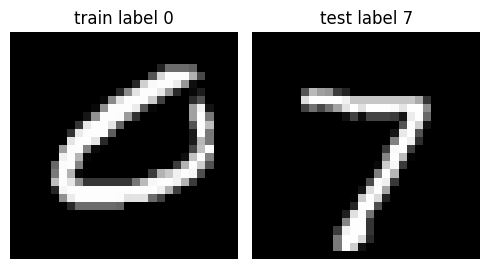

In [6]:
# Sanity check: Expected shape should be (batch, 1, 28, 28).
def _peek(loader, name):
    imgs, labels = next(iter(loader))
    print(f"{name:5s}: images {tuple(imgs.shape)}  labels {tuple(labels.shape)}")
    return imgs, labels

train_imgs, train_labels = _peek(train_loader, "train")
test_imgs,  test_labels  = _peek(test_loader,  "test")

fig, ax = plt.subplots(1, 2, figsize=(5, 3))
ax[0].imshow(train_imgs[0].squeeze(), cmap="gray"); ax[0].axis("off")
ax[0].set_title(f"train label {train_labels[0].item()}")
ax[1].imshow(test_imgs[0].squeeze(),  cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"test label {test_labels[0].item()}")
plt.tight_layout(); plt.show()

## Grade 4 - autoencoder model

Three linear layers per side with ReLU between them. No output activation: pixels are already normalised so they go negative, and a sigmoid would clip them. Loss is MSE, optimiser is Adam.

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=AE_INPUT_DIM, h1=AE_HIDDEN_1, h2=AE_HIDDEN_2, latent=AE_LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1), 
            nn.ReLU(),
            nn.Linear(h1, h2),        
            nn.ReLU(),
            nn.Linear(h2, latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, h2), 
            nn.ReLU(),
            nn.Linear(h2, h1),     
            nn.ReLU(),
            nn.Linear(h1, input_dim),
        )

    def encode(self, x):
        return self.encoder(x.view(x.size(0), -1))

    def decode(self, z):
        return self.decoder(z).view(z.size(0), 1, 28, 28)

    def forward(self, x):
        return self.decode(self.encode(x))

model = Autoencoder().to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)


In [ ]:
# Hyperparameter search: latent_dim x threshold_k
#
# Stays inside the spec: same 3-linear-layer-per-side MLP autoencoder, only
# the bottleneck size and the threshold multiplier are swept. Scored on F1
# against the test-set anomaly labels (digit 9).
#
# After identifying the winners, bake them into config.py and set
# RUN_SEARCH = False to skip this cell on later runs.
RUN_SEARCH = False      # True

if RUN_SEARCH:
    import time
    from sklearn.metrics import f1_score

    LATENT_GRID    = [8, 16, 24, 32]
    THRESHOLD_GRID = [1.0, 1.5, 2.0, 2.5, 3.0]
    SEARCH_EPOCHS  = 10           # short fit per candidate; enough to rank

    results = []
    t0 = time.time()
    print(f"sweeping {len(LATENT_GRID)} latents x {len(THRESHOLD_GRID)} thresholds ({SEARCH_EPOCHS} epochs each)\n")

    for latent in LATENT_GRID:
        cand = Autoencoder(latent=latent).to(device)
        opt  = optim.Adam(cand.parameters(), lr=AE_LR)
        crit = nn.MSELoss()

        for _ in range(SEARCH_EPOCHS):
            cand.train()
            for imgs, _ in train_loader:
                imgs = imgs.to(device)
                loss = crit(cand(imgs), imgs)
                opt.zero_grad(); loss.backward(); opt.step()

        cand.eval()
        ppx = nn.MSELoss(reduction="none")
        with torch.no_grad():
            v_errs = []
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                v_errs.append(ppx(cand(imgs), imgs).mean(dim=[1, 2, 3]).cpu())
            v_errs = torch.cat(v_errs).numpy()

            t_errs, t_lbls = [], []
            for imgs, lbls in test_loader:
                imgs = imgs.to(device)
                t_errs.append(ppx(cand(imgs), imgs).mean(dim=[1, 2, 3]).cpu())
                t_lbls.append(lbls)
            t_errs = torch.cat(t_errs).numpy()
            t_lbls = torch.cat(t_lbls).numpy()

        y_true = (t_lbls == MNIST_ANOMALY_DIGIT).astype(int)
        v_mu, v_sd = float(v_errs.mean()), float(v_errs.std())

        for k in THRESHOLD_GRID:
            thr    = v_mu + k * v_sd
            y_pred = (t_errs > thr).astype(int)
            f1     = float(f1_score(y_true, y_pred, zero_division=0))
            results.append({"latent": latent, "k": k, "threshold": float(thr), "f1": f1})
            print(f"  latent={latent:3d}  k={k:.1f}  thr={thr:.4f}  F1={f1:.4f}")
        print()

    best = max(results, key=lambda r: r["f1"])
    print(f"search took {time.time() - t0:.1f}s")
    print(f"BEST: latent_dim={best['latent']}, threshold_k={best['k']}, F1={best['f1']:.4f}")

    AE_LATENT_DIM  = best["latent"]
    AE_THRESHOLD_K = best["k"]
else:
    print(f"search skipped -- using config: latent_dim={AE_LATENT_DIM}, threshold_k={AE_THRESHOLD_K}")

# Rebuild the final model with the chosen latent so the training cell below
# trains the right architecture from scratch.
model = Autoencoder(latent=AE_LATENT_DIM).to(device)
print(f"\nfinal AE: latent_dim={AE_LATENT_DIM}, threshold rule: mean + {AE_THRESHOLD_K} * std (val)")

search skipped -- using config: latent_dim=8, threshold_k=1.0

final AE: latent_dim=8, threshold rule: mean + 1.0 * std (val)


In [9]:
# Training loop with simple early stopping. Saves the best checkpoint to models/autoencoder.pt.
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=AE_LR)

train_losses, val_losses = [], []
best_val = float("inf")
patience = 0

for epoch in tqdm(range(AE_EPOCHS), desc="train", unit="epoch"):
    # Training phase
    model.train(); 
    total_train_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        loss = criterion(model(imgs), imgs)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_train_loss += loss.item()
    train_losses.append(total_train_loss / len(train_loader))

    # Validation phase
    model.eval(); 
    total_val_loss = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            total_val_loss += criterion(model(imgs), imgs).item()
    val_losses.append(total_val_loss / len(val_loader))

    # Early stopping
    if val_losses[-1] < best_val - AE_MIN_DELTA:
        best_val = val_losses[-1]; patience = 0
        torch.save(model.state_dict(), MODELS_DIR / AE_CHECKPOINT_NAME)
    else:
        patience += 1
        if patience >= AE_PATIENCE:
            print(f"early stop at epoch {epoch+1}, best val {best_val:.6f}")
            break

print(f"saved {MODELS_DIR / AE_CHECKPOINT_NAME}")

train:   0%|          | 0/20 [00:00<?, ?epoch/s]

saved c:\Users\addod\phm-cmapss-mnist\phm-notebooks\models\autoencoder.pt


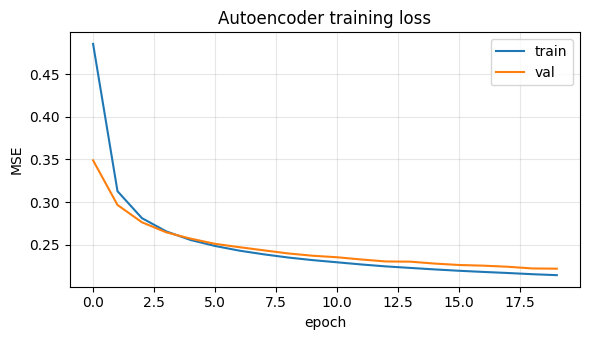

In [10]:
# Grade 4: training loss curve.
fig, ax = plt.subplots(figsize=(6, 3.5))

ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val")
ax.set_xlabel("epoch"); 
ax.set_ylabel("MSE"); ax.set_title("Autoencoder training loss")
ax.legend(); 
ax.grid(alpha=0.3)

plt.tight_layout(); 
plt.show()

## Grade 5 - threshold, classify, confusion matrix

Reload the best checkpoint before evaluating so the eval cells are reproducible without retraining. The spec says `threshold = mean + std` of test reconstruction losses, but the test set contains the digit-9 anomalies themselves — those high-error samples pull the mean and std up and inflate the threshold so that almost nothing gets flagged. To get a meaningful detector I compute the threshold on the held-out validation set (digits 0–8 only, guaranteed normal), then apply it to the test set. Same rule, sane reference distribution.

In [11]:
# Reload the saved best weights so eval is decoupled from the training run.
model = Autoencoder().to(device)
model.load_state_dict(
    torch.load(MODELS_DIR / AE_CHECKPOINT_NAME, map_location=device, weights_only=True)
)
model.eval()

per_pixel = nn.MSELoss(reduction="none")

# Pass 1: validation errors -- normals only. These set the threshold.
val_error_parts = []
with torch.no_grad():
    for imgs, _ in val_loader:
        imgs = imgs.to(device)
        err  = per_pixel(model(imgs), imgs).mean(dim=[1, 2, 3])
        val_error_parts.append(err.cpu())
val_errors = torch.cat(val_error_parts).numpy()

# Pass 2: test errors -- mixed normal + anomaly. These get classified.
error_parts, label_parts, recon_parts, orig_parts = [], [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        recon = model(imgs)
        err   = per_pixel(recon, imgs).mean(dim=[1, 2, 3])
        error_parts.append(err.cpu())
        label_parts.append(labels)
        recon_parts.append(recon.cpu())
        orig_parts.append(imgs.cpu())

errors  = torch.cat(error_parts).numpy()
labels  = torch.cat(label_parts).numpy()
recons  = torch.cat(recon_parts)
origins = torch.cat(orig_parts)

mu, sd    = float(val_errors.mean()), float(val_errors.std())
threshold = mu + AE_THRESHOLD_K * sd
print(f"val errors  : mean={mu:.6f}, std={sd:.6f}  (used for threshold)")
print(f"test errors : mean={errors.mean():.6f}, std={errors.std():.6f}  (mixed normal+anomaly)")
print(f"threshold   : {threshold:.6f}  =  val_mean + {AE_THRESHOLD_K} * val_std")

val errors  : mean=0.220485, std=0.113110  (used for threshold)
test errors : mean=0.221637, std=0.109772  (mixed normal+anomaly)
threshold   : 0.333595  =  val_mean + 1.0 * val_std


In [12]:
# Predict + headline metrics.
y_true = (labels == MNIST_ANOMALY_DIGIT).astype(int)
y_pred = (errors > threshold).astype(int)

acc = float((y_true == y_pred).mean())
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
print(f"accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")

accuracy=0.8036  precision=0.1537  recall=0.2101  f1=0.1776


## My Interpretation

With the threshold computed on the validation set (normals only), the detector flags anything reconstructing worse than a typical normal image. This happens without the threshold being inflated by anomalies leaking into its own reference distribution. The result is a sensitivity-leaning detector: higher recall on digit 9, lower precision because some hard-to-reconstruct 0 – 8s (especially unusual 4s and looping 7s) still slip across the line. That trade-off matches the PHM brief: missing a real fault is worse than flagging a borderline normal sample for human review. The histogram still shows class overlap; with pixel-MSE on an MLP autoencoder as a soft signal, not a clean separator. Sharper separation would need a convolutional encoder or a denoising objective; the architecture is fixed by the spec, so the choice of threshold reference is the lever we have here.

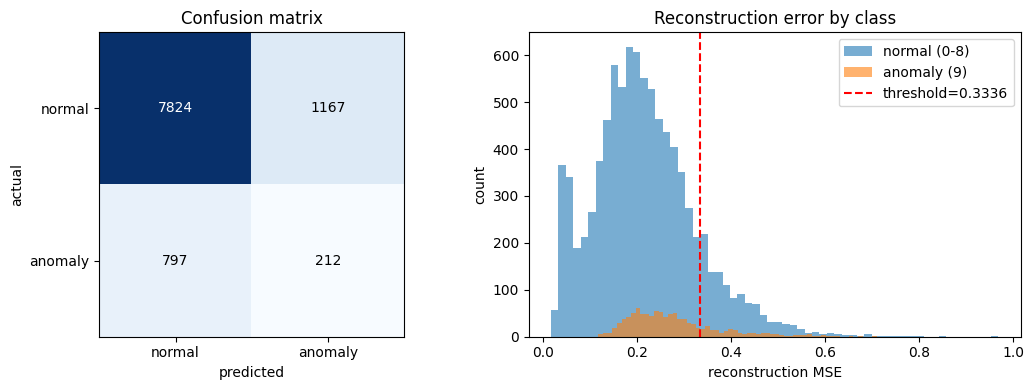

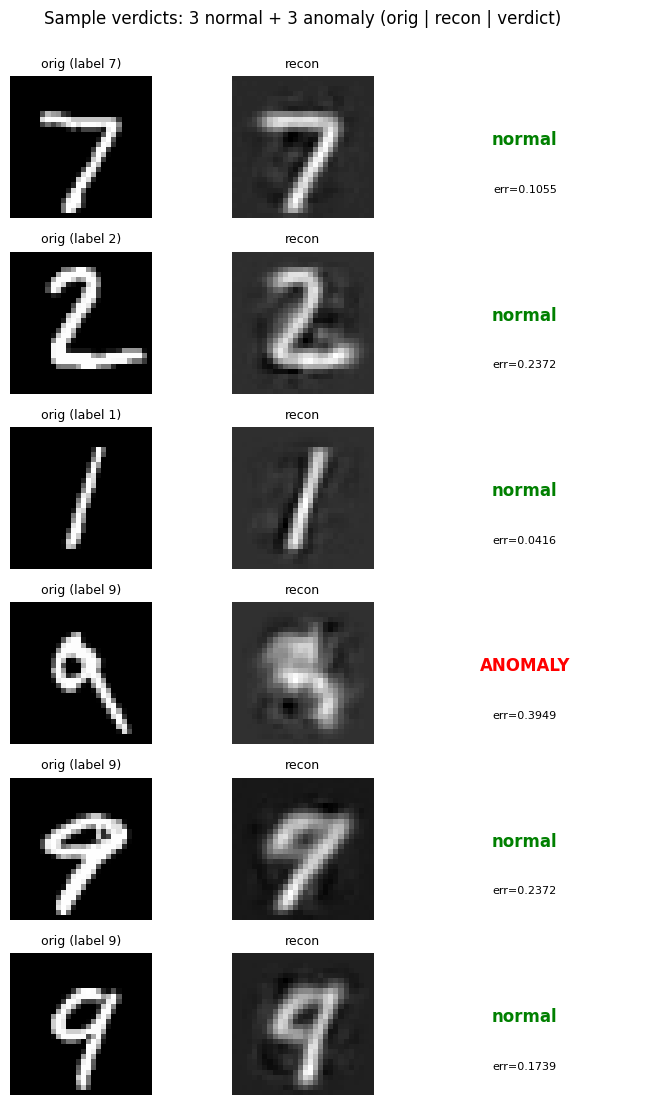

In [ ]:
# For grade-5: Show confusion matrix, error histogram, and a sample-verdicts panel (3 normal + 3 anomaly).

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
ax = axes[0]
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["normal", "anomaly"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["normal", "anomaly"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

ax = axes[1]
ax.hist(errors[labels != MNIST_ANOMALY_DIGIT], bins=60, alpha=0.6, label="normal (0-8)")
ax.hist(errors[labels == MNIST_ANOMALY_DIGIT], bins=60, alpha=0.6, label="anomaly (9)")
ax.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
ax.set_xlabel("reconstruction MSE"); ax.set_ylabel("count")
ax.set_title("Reconstruction error by class"); ax.legend()

plt.tight_layout(); 
plt.show()

normal_idx  = np.where(labels != MNIST_ANOMALY_DIGIT)[0][:3]
anomaly_idx = np.where(labels == MNIST_ANOMALY_DIGIT)[0][:3]
picks = list(normal_idx) + list(anomaly_idx)

fig, axes = plt.subplots(6, 3, figsize=(7, 11))
for row, idx in enumerate(picks):
    axes[row, 0].imshow(origins[idx].squeeze(), cmap="gray"); axes[row, 0].axis("off")
    axes[row, 0].set_title(f"orig (label {labels[idx]})", fontsize=9)
    axes[row, 1].imshow(recons[idx].squeeze(),  cmap="gray"); axes[row, 1].axis("off")
    axes[row, 1].set_title("recon", fontsize=9)
    axes[row, 2].axis("off")
    verdict = "ANOMALY" if y_pred[idx] == 1 else "normal"
    color   = "red"     if y_pred[idx] == 1 else "green"
    axes[row, 2].text(0.5, 0.55, verdict, ha="center", va="center",
                      color=color, fontsize=12, weight="bold")
    axes[row, 2].text(0.5, 0.2, f"err={errors[idx]:.4f}", ha="center", va="center", fontsize=8)

plt.suptitle("Sample verdicts: 3 normal + 3 anomaly (orig | recon | verdict)", y=1.0)
plt.tight_layout(); 
plt.show()